## Hybrid v2 vs Sparse+UserBatch vs Base (MovieLens-style CF)

This notebook compares three approaches using the same `splits.pt` data:

- **Base model**: Adam + random batching (no PSO, no multiprocessing comms)
- **Hybrid v2 (old)**: `hybrid_adam_pso_workers_pso_v2_results.pt`
- **Hybrid v2 (sparse+userbatch)**: `hybrid_adam_pso_workers_pso_v2_sparse_userbatch_results.pt` (generated by `hybrid_adam_pso_workers_pso_v2_sparse_userbatch.py`)

We compare:

- Loss curves (global test loss)
- Communication volume (reads/writes + estimated bytes) from `comm_stats`


In [1]:
import os
import time
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

torch.set_num_threads(1)
DEVICE = torch.device('cpu')

SPLITS_PATH = 'splits.pt'
OLD_HYBRID_RESULTS = 'hybrid_adam_pso_workers_pso_v2_results.pt'
NEW_HYBRID_RESULTS = 'hybrid_adam_pso_workers_pso_v2_sparse_userbatch_results.pt'

# Base model settings (kept consistent with hybrid scripts)
EMB_DIM = 16
HIDDEN_DIM = 16
DROPOUT = 0.1
DROPOUT_EMB = 0.2

NUM_ROUNDS = 5
GLOBAL_EPOCHS_PER_ROUND = 4
BASE_LR = 1e-3
BATCH_SIZE = 2048
MAX_SAMPLES_PER_SPLIT = 20000
NUM_ADAM_TRAIN_SPLITS = 2


In [2]:
def load_tensor_splits(max_samples_per_split: int | None = MAX_SAMPLES_PER_SPLIT):
    assert os.path.exists(SPLITS_PATH), f"{SPLITS_PATH} not found. Generate it first."
    raw_splits = torch.load(SPLITS_PATH)

    # global id ranges from full data (train+test) before subsampling
    all_X_full = torch.cat(
        [torch.cat([s['X_train'], s['X_test']], dim=0) for s in raw_splits],
        dim=0,
    )
    n_users_global = int(all_X_full[:, 0].max().item()) + 1
    n_movies_global = int(all_X_full[:, 1].max().item()) + 1

    tensor_splits = []
    for s in raw_splits:
        X_train, y_train = s['X_train'], s['y_train']
        X_test, y_test = s['X_test'], s['y_test']

        if max_samples_per_split is not None and X_train.size(0) > max_samples_per_split:
            X_train = X_train[:max_samples_per_split].clone()
            y_train = y_train[:max_samples_per_split].clone()
        if max_samples_per_split is not None and X_test.size(0) > max_samples_per_split:
            X_test = X_test[:max_samples_per_split].clone()
            y_test = y_test[:max_samples_per_split].clone()

        tensor_splits.append({'X_train': X_train, 'y_train': y_train, 'X_test': X_test, 'y_test': y_test})

    return tensor_splits, n_users_global, n_movies_global


def make_combined_test_loader(tensor_splits, batch_size=BATCH_SIZE):
    X_all = torch.cat([s['X_test'] for s in tensor_splits], dim=0)
    y_all = torch.cat([s['y_test'] for s in tensor_splits], dim=0)
    ds = TensorDataset(X_all, y_all)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


def make_combined_train_loader(tensor_splits, batch_size=BATCH_SIZE):
    X_all = torch.cat([s['X_train'] for s in tensor_splits], dim=0)
    y_all = torch.cat([s['y_train'] for s in tensor_splits], dim=0)
    ds = TensorDataset(X_all, y_all)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)


In [3]:
class BaseCollabFiltering(nn.Module):
    """Baseline CF model: dense embeddings + same MLP head."""

    def __init__(self, n_users, n_movies, emb_dim=EMB_DIM, hidden=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.dropout_emb = DROPOUT_EMB

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
            nn.ReLU(),
        )

    def forward(self, user, movie):
        u = F.dropout(self.user_emb(user), p=self.dropout_emb, training=self.training)
        m = F.dropout(self.movie_emb(movie), p=self.dropout_emb, training=self.training)
        x = torch.cat([u, m], dim=1)
        return self.mlp(x).squeeze()


loss_fn = nn.MSELoss()


@torch.no_grad()
def evaluate_model(model, data_loader):
    model.eval()
    total = 0.0
    n = 0
    for Xb, yb in data_loader:
        Xb = Xb.to(DEVICE)
        yb = yb.float().to(DEVICE)
        preds = model(Xb[:, 0].long(), Xb[:, 1].long())
        total += loss_fn(preds, yb).item()
        n += 1
    return total / max(n, 1)


def train_one_epoch_baseline(model, train_loader, optimizer):
    model.train()
    total = 0.0
    n = 0
    for Xb, yb in train_loader:
        Xb = Xb.to(DEVICE)
        yb = yb.float().to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        preds = model(Xb[:, 0].long(), Xb[:, 1].long())
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        total += loss.item()
        n += 1
    return total / max(n, 1)


In [4]:
def run_baseline_base_model(
    tensor_splits,
    n_users_global,
    n_movies_global,
    num_rounds=NUM_ROUNDS,
    global_epochs_per_round=GLOBAL_EPOCHS_PER_ROUND,
    base_lr=BASE_LR,
    num_adam_train_splits=NUM_ADAM_TRAIN_SPLITS,
):
    """Baseline with the same round/split schedule as hybrid, but no PSO and no comms."""

    model = BaseCollabFiltering(n_users_global, n_movies_global).to(DEVICE)
    test_loader = make_combined_test_loader(tensor_splits)

    history = {
        'round': [],
        'global_train_loss': [],
        'global_test_loss': [],
    }

    start = time.time()
    for r in range(num_rounds):
        split_indices = list(range(len(tensor_splits)))
        random.seed(SEED + r)
        random.shuffle(split_indices)

        n_train = num_adam_train_splits if num_adam_train_splits is not None else len(tensor_splits)
        n_train = min(n_train, len(tensor_splits))
        train_splits = [tensor_splits[i] for i in split_indices[:n_train]]
        train_loader = make_combined_train_loader(train_splits)

        optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)
        for _ in range(global_epochs_per_round):
            train_one_epoch_baseline(model, train_loader, optimizer)

        # record end-of-round metrics for comparability
        train_loss = evaluate_model(model, train_loader)
        test_loss = evaluate_model(model, test_loader)
        history['round'].append(r)
        history['global_train_loss'].append(float(train_loss))
        history['global_test_loss'].append(float(test_loss))

    comm_stats = {
        'num_rounds': len(history['round']),
        'num_workers': 0,
        'payload_mode': 'none',
        'total_queue_writes': 0,
        'total_queue_reads': 0,
        'bytes_full_model': 0,
        'bytes_per_worker_read': 0,
        'processing_time_seconds': time.time() - start,
    }

    return history, comm_stats


In [8]:
def load_results_if_present(path: str):
    if not os.path.exists(path):
        return None
    obj = torch.load(path, map_location='cpu')
    return {
        'path': path,
        'history': obj.get('history', {}),
        'comm_stats': obj.get('comm_stats', {}),
    }


tensor_splits, n_users_global, n_movies_global = load_tensor_splits()
print('n_users_global:', n_users_global)
print('n_movies_global:', n_movies_global)

old_hybrid = load_results_if_present(OLD_HYBRID_RESULTS)
new_hybrid = load_results_if_present(NEW_HYBRID_RESULTS)

if old_hybrid is None:
    print(f"Missing {OLD_HYBRID_RESULTS}. Run hybrid_adam_pso_workers_pso_v2.py first.")
else:
    print(f"Loaded old hybrid results: {old_hybrid['path']}")

if new_hybrid is None:
    print(f"Missing {NEW_HYBRID_RESULTS}. Run hybrid_adam_pso_workers_pso_v2_sparse_userbatch.py first.")
else:
    print(f"Loaded new hybrid results: {new_hybrid['path']}")

base_history, base_comm = run_baseline_base_model(tensor_splits, n_users_global, n_movies_global)
print('Baseline done.')


C:\Users\gouth\AppData\Local\Temp\ipykernel_21160\1469008092.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_splits = torch.load(SPLITS_PATH)
C:\Users\gouth\AppData\

n_users_global: 1000
n_movies_global: 11459
Loaded old hybrid results: hybrid_adam_pso_workers_pso_v2_results.pt
Loaded new hybrid results: hybrid_adam_pso_workers_pso_v2_sparse_userbatch_results.pt
Baseline done.


## Communication comparison

For the hybrid approaches, `comm_stats` comes directly from the saved `.pt` results.

- **Reads/Writes**: queue reads/writes between main and workers
- **bytes_full_model**: estimated size of a full float32 model broadcast
- **bytes_per_worker_read**: size of the minimal worker payload (alpha+seed+losses)

Baseline has **no multiprocessing comms** here.


In [9]:
def comm_summary(name: str, comm: dict):
    if comm is None:
        return {'name': name, 'available': False}

    bytes_full_model = int(comm.get('bytes_full_model', 0) or 0)
    bytes_per_worker_read = int(comm.get('bytes_per_worker_read', 0) or 0)
    num_workers = int(comm.get('num_workers', 0) or 0)
    total_reads = int(comm.get('total_queue_reads', 0) or 0)
    total_writes = int(comm.get('total_queue_writes', 0) or 0)
    num_rounds = int(comm.get('num_rounds', 0) or 0)
    t = float(comm.get('processing_time_seconds', float('nan')))

    # Rough estimate: per round, main broadcasts full model once; workers send minimal payload.
    approx_total_bytes = 0
    if num_rounds > 0 and num_workers > 0:
        approx_total_bytes += num_rounds * bytes_full_model
        approx_total_bytes += total_reads * bytes_per_worker_read

    return {
        'name': name,
        'available': True,
        'num_rounds': num_rounds,
        'num_workers': num_workers,
        'total_queue_writes': total_writes,
        'total_queue_reads': total_reads,
        'bytes_full_model': bytes_full_model,
        'bytes_per_worker_read': bytes_per_worker_read,
        'approx_total_bytes': approx_total_bytes,
        'processing_time_seconds': t,
        'payload_mode': comm.get('payload_mode', 'unknown'),
    }


summaries = []

summaries.append(comm_summary('Base (Adam, random batching)', base_comm))

summaries.append(comm_summary('Hybrid v2 (old)', None if old_hybrid is None else old_hybrid.get('comm_stats')))

summaries.append(comm_summary('Hybrid v2 (sparse+userbatch)', None if new_hybrid is None else new_hybrid.get('comm_stats')))

summaries

[{'name': 'Base (Adam, random batching)',
  'available': True,
  'num_rounds': 5,
  'num_workers': 0,
  'total_queue_writes': 0,
  'total_queue_reads': 0,
  'bytes_full_model': 0,
  'bytes_per_worker_read': 0,
  'approx_total_bytes': 0,
  'processing_time_seconds': 14.343594551086426,
  'payload_mode': 'none'},
 {'name': 'Hybrid v2 (old)',
  'available': True,
  'num_rounds': 5,
  'num_workers': 5,
  'total_queue_writes': 25,
  'total_queue_reads': 25,
  'bytes_full_model': 799556,
  'bytes_per_worker_read': 40,
  'approx_total_bytes': 3998780,
  'processing_time_seconds': 48.120744705200195,
  'payload_mode': 'minimal'},
 {'name': 'Hybrid v2 (sparse+userbatch)',
  'available': True,
  'num_rounds': 5,
  'num_workers': 5,
  'total_queue_writes': 25,
  'total_queue_reads': 25,
  'bytes_full_model': 799556,
  'bytes_per_worker_read': 40,
  'approx_total_bytes': 3998780,
  'processing_time_seconds': 67.10035276412964,
  'payload_mode': 'minimal'}]

### Hybrid Adam–PSO **without** optimizations

Dense embeddings, standard **Adam**, and random **DataLoader** batching (as in `hybrid_adam_pso_workers_pso_v2.py`). Curves are loaded **only** from `hybrid_adam_pso_workers_pso_v2_results.pt` — no re-training in this cell.

In [ ]:
# Plot hybrid WITHOUT optimizations (saved .pt only)
path = OLD_HYBRID_RESULTS
if not os.path.exists(path):
    print(f"Missing {path}. Run hybrid_adam_pso_workers_pso_v2.py first.")
else:
    d = torch.load(path, map_location="cpu")
    h = d.get("history", {})
    rounds = h.get("round", [])

    fig, ax = plt.subplots(figsize=(8, 4.5))
    if rounds and h.get("global_test_loss"):
        ax.plot(rounds, h["global_test_loss"], marker="o", label="Global test MSE")
    if rounds and h.get("global_train_loss"):
        ax.plot(rounds, h["global_train_loss"], marker="s", label="Global train MSE")

    ax.set_xlabel("Communication round")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title("Hybrid Adam–PSO without SparseAdam / user batching")
    if rounds:
        ax.set_xticks(rounds)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    out_hybrid_no_opt = "hybrid_v2_without_optimizations_loss.png"
    plt.savefig(out_hybrid_no_opt, dpi=150)
    print("Saved:", out_hybrid_no_opt)
    plt.show()

## Loss comparison plot

We plot **global test loss vs round** for all approaches.

- Hybrid curves are loaded from their `.pt` histories.
- Baseline curve is computed in this notebook.


Saved: hybrid_v2_sparse_userbatch_base_loss_comparison.png


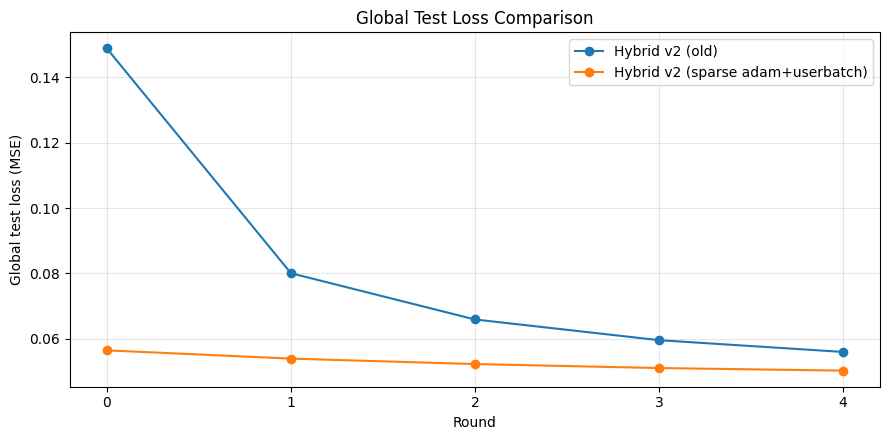

In [12]:
plt.figure(figsize=(9, 4.5))

# Baseline 
# # plt.plot(base_history['round'], base_history['global_test_loss'], marker='o', label='Base (Adam, random batching)')

# Old hybrid
if old_hybrid is not None and 'global_test_loss' in old_hybrid['history']:
    plt.plot(old_hybrid['history']['round'], old_hybrid['history']['global_test_loss'], marker='o', label='Hybrid v2 (old)')

# New hybrid
if new_hybrid is not None and 'global_test_loss' in new_hybrid['history']:
    plt.plot(new_hybrid['history']['round'], new_hybrid['history']['global_test_loss'], marker='o', label='Hybrid v2 (sparse adam+userbatch)')

plt.xlabel('Round')
plt.ylabel('Global test loss (MSE)')
plt.title('Global Test Loss Comparison')

_rounds = []
if new_hybrid is not None and new_hybrid['history'].get('round'):
    _rounds = new_hybrid['history']['round']
elif old_hybrid is not None and old_hybrid['history'].get('round'):
    _rounds = old_hybrid['history']['round']
elif base_history.get('round'):
    _rounds = base_history['round']
if _rounds:
    plt.xticks(_rounds)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_plot = 'hybrid_v2_sparse_userbatch_base_loss_comparison.png'
plt.savefig(out_plot, dpi=150)
print('Saved:', out_plot)
plt.show()

## Notes

- If either hybrid results file is missing, run its corresponding script to generate the `.pt` file, then re-run the notebook cells.
- The comms estimate shown is a **rough total** based on:
  - one full-model broadcast per round (`bytes_full_model`)
  - one minimal worker payload per successful worker result (`bytes_per_worker_read` × `total_queue_reads`)
